In [35]:
import pandas as pd

# Load job descriptions (contains job_title and extracted text)
df_jobs = pd.read_csv("all_jobreq_extractedentity.csv")  # Change filename if needed

# Combine job title with extracted job description (or use raw text)
df_jobs["combined_text"] = df_jobs["job_title"] + " " + df_jobs["extracted_entities_from_job_req"]

# Encode job titles as numbers for training
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_jobs["encoded_job_title"] = label_encoder.fit_transform(df_jobs["job_title"])

# View the dataset
df_jobs.head()


In [36]:
df_resumes = pd.read_csv("all_resumes_extractedentity.csv")  # Load resumes
resumes_text = df_resumes["extracted_entities_from_resume"]  # or use extracted_raw_text

# Convert resume text into numerical features


🔹 Job Title Mapping:
{20: 'HR STAFF', 2: 'ADMIN ASSISTANT', 47: 'WELDER', 42: 'SALES SUPERVISOR', 25: 'LAUNDRY ATTENDANT', 34: 'PASSENGER SERVICE AGENT', 30: 'OFFICE STAFF', 8: 'COMPLIANCE OFFICER', 40: 'SALES REPRESENTATIVE', 0: 'ACCOUNTING HEAD', 43: 'SALESMAN', 4: 'BARISTA', 35: 'PRODUCTION HELPER', 15: 'FEMALE SERVICE CREW', 27: 'MANAGEMENT TRAINEE', 7: 'CLAIMS-IN-CHARGE', 38: 'SALES CLERK', 41: 'SALES SERVICE DEVELOPER', 12: 'EXTRUCT SALESMAN', 3: 'BAKER', 46: 'SERVICE CREW', 44: 'SALESMAN ', 17: 'FINISHING CARPENTER', 22: 'JAPANESE BILINGUAL', 11: 'DRIVER', 19: 'HR COORDINATOR', 13: 'FABRICATOR', 39: 'SALES REPRENSETATIVE', 45: 'SECURITY GUARD', 16: 'FIELD SALES SUPERVISOR', 33: 'PART-TIME-BARISTA', 14: 'FEMALE OFFICE STAFF', 18: 'FOOD PREPARATION MALE', 9: 'CREDIT & COLLECTION STAFF', 5: 'BRANCH SECRETARY', 28: 'MANDARIN BILINGUAL', 31: 'OPERATIONS MANAGER', 6: 'CASHIER', 37: 'RETAILS STORE SPECIALIST', 26: 'MALE SERVICE STAFF', 1: 'ACCOUNTS SPECIALIST', 10: 'DIGITAL CLIENT SUCC

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use TF-IDF to convert job descriptions & resumes into vectors
vectorizer = TfidfVectorizer(max_features=5000)  # Limit features to avoid overfitting
X_jobs = vectorizer.fit_transform(df_jobs["combined_text"])  # Job descriptions
X_resumes = vectorizer.transform(resumes_text)  # Resumes

y_jobs = df_jobs["encoded_job_title"]  # Job title labels


c:\Users\Acer\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [38]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Split job descriptions dataset for training
X_train, X_test, y_train, y_test = train_test_split(X_jobs, y_jobs, test_size=0.2, stratify=y_jobs, random_state=42)

# Train XGBoost classifier
model = xgb.XGBClassifier(objective="multi:softprob", eval_metric="mlogloss")
model.fit(X_train, y_train)

# Evaluate model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


c:\Users\Acer\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Acer\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [00:42:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [39]:
# Predict job title for each resume
resume_predictions = model.predict(X_resumes)

# Convert predictions back to job title names
predicted_job_titles = label_encoder.inverse_transform(resume_predictions)

# Display results
df_resumes["predicted_job_title"] = predicted_job_titles
df_resumes[["extracted_entities_from_resume", "predicted_job_title"]].head()


🔹 Model Accuracy: 0.51

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         1
           9       0.33      1.00      0.50         1
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         1
          12       1.00      1.00      1.00         1
          13       0.50      1.00      0.67         3
          14       1.00      0.67      0.80         3
          16       0.00      0.00      0.00         1
          18       1.00      0.3

c:\Users\Acer\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Acer\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Acer\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

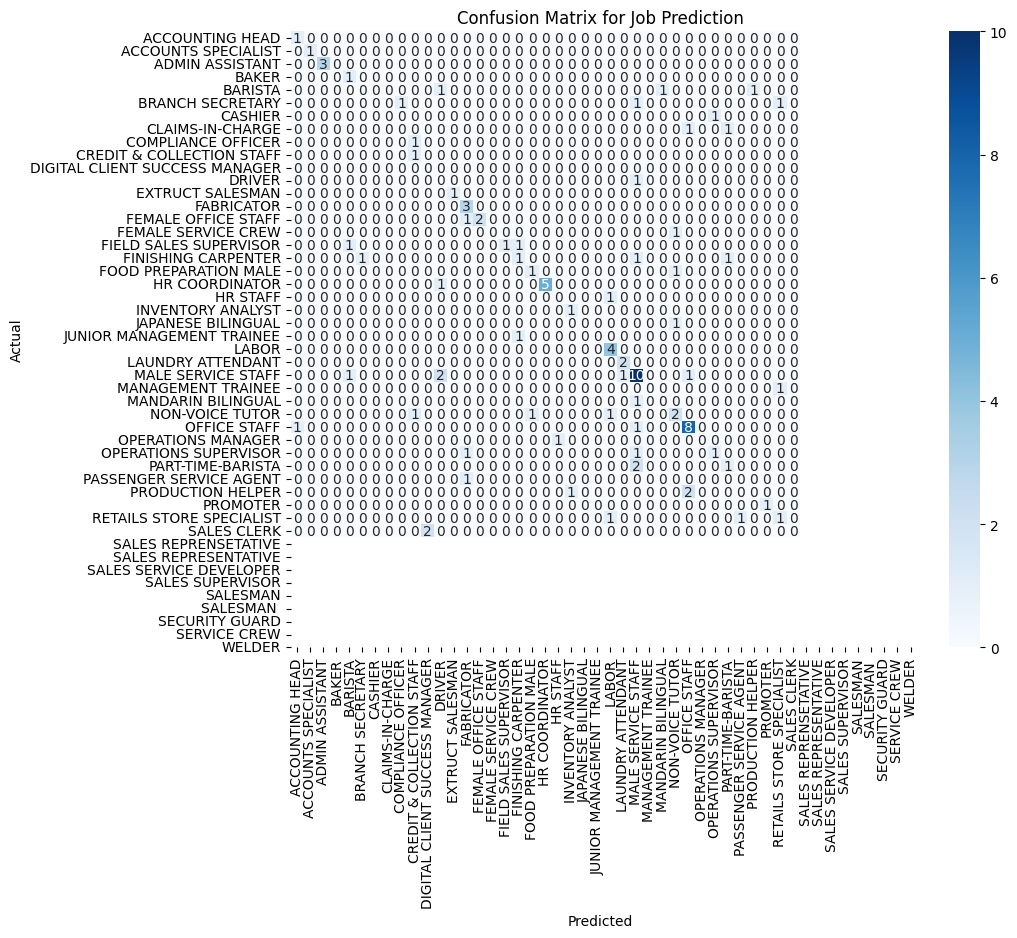

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Job Prediction')
plt.show()


In [51]:
def predict_job(new_resume_text):
    # Compute embedding for new resume
    new_resume_embedding = embedding_model.encode([new_resume_text], convert_to_tensor=True)

    # Compute similarity with job descriptions
    similarity_scores = util.cos_sim(new_resume_embedding, jobreq_embeddings).cpu().numpy()

    # Predict job title using XGBoost
    predicted_label = model.predict(similarity_scores)[0]

    # Convert label back to job title
    predicted_job_title = label_encoder.inverse_transform([predicted_label])[0]

    # Get confidence score
    confidence = np.max(similarity_scores) * 100

    return predicted_job_title, confidence

# Example prediction
new_resume = """To obtain a position that will allow me to make effective use of
the expertise, knowledge, and abilities I have acquired and also
apply my training and experience, responsible, hardworking, and
diverse in the field of specialization will serve not only as career
advancement but as a challenge to my profession as well as to
contribute to the company’s growth. Train Driver/Operator with more
than 10 years of experience in Railway Mainline Service Operations
and Trackwork Locomotive Operator with 4 years of experience. I
have also interpersonal communication skills, customer-oriented,
problem-solving skills, functional, well-organized, ability to work in
a team, self-motivation, time management, and computer literate
skills, Details that will validate all my personal information are here.
I hope this will serve as well in advance for the job opportunity. With
a great field of knowledge in Tunnel construction and good team
performance, working best under pressure, and learning more about
the job to achieve the Safety and Security of Transportation as a
Train Driver / Locomotive Operator and Train Station Supervisor, I
look forward to hearing from you. Hope for your kind consideration.
"""
predicted_job, confidence = predict_job(new_resume)
print(f"Predicted Job: {predicted_job} ({confidence:.2f}%)")


Predicted Job: SALES CLERK (15.48%)
